Loads training and testing data.
Combines them into one dataset.
Aggregates from Port × Week into Week-level data.
Creates Month.
Creates Quarter_Month.
Checks the quarterly activity pattern.

Principal Component Analysis revealed that maritime activity can largely be summarized by three underlying dimensions. The first component explained 62.7% of total variance and was primarily associated with tanker counts, cargo vessel counts, and unique vessel activity, suggesting an overall maritime activity factor. The second component explained 16.8% of variance and was dominated by vessel length, representing a vessel size factor. The third component explained 11.2% of variance and was associated with draft, cargo traffic, and vessel counts, suggesting a commercial traffic intensity factor. Together, the first three principal components explained approximately 90.6% of total variance in AIS-derived maritime features.

In [2]:
import pandas as pd

train_df = pd.read_csv("/Users/calebarrivillaga/Desktop/UMIS_Homework/696_Milestone II/maritime-market-ml/models/unsupervised/merged_3W_training_data.csv")

test_df = pd.read_csv("/Users/calebarrivillaga/Desktop/UMIS_Homework/696_Milestone II/maritime-market-ml/models/unsupervised/merged_3W_testing_data.csv")

combined_df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

weekly_df = (
    combined_df.groupby("Week")
    .agg({
        "Tanker_Vessels": "sum",
        "Cargo_Vessels": "sum",
        "Draft": "mean",
        "Avg_SOG": "mean",
        "Avg_Length": "mean",
        "Unique_Vessels": "sum"
    })
    .reset_index()
)

weekly_df["Month"] = pd.to_datetime(
    weekly_df["Week"]
).dt.month

weekly_df["Quarter_Month"] = (
    ((weekly_df["Month"] - 1) % 3) + 1
)

weekly_df["Quarter_Start"] = (
    weekly_df["Quarter_Month"] == 1
)

# Save the quarterly summary
quarterly_summary = (
    weekly_df.groupby("Quarter_Month")[
        [
            "Tanker_Vessels",
            "Cargo_Vessels",
            "Unique_Vessels"
        ]
    ]
    .mean()
)

print(weekly_df.shape)
print(weekly_df.isnull().sum())

quarterly_summary

weekly_df.head()

(260, 10)
Week              0
Tanker_Vessels    0
Cargo_Vessels     0
Draft             0
Avg_SOG           0
Avg_Length        0
Unique_Vessels    0
Month             0
Quarter_Month     0
Quarter_Start     0
dtype: int64


,Week,Tanker_Vessels,Cargo_Vessels,Draft,Avg_SOG,Avg_Length,Unique_Vessels,Month,Quarter_Month,Quarter_Start
0,2019-01-06,969,1863,11.586552,10.068000,205.128667,2832,1,1,True
1,2019-01-13,1048,2205,11.404138,10.394138,211.236897,3253,1,1,True
2,2019-01-20,1057,2259,11.218333,10.847667,205.118667,3316,1,1,True
3,2019-01-27,1037,2205,11.423333,10.063000,206.914000,3242,1,1,True
4,2019-02-03,997,2142,11.196000,10.242333,204.906333,3139,2,2,False


In [3]:
#Step 1: Build PCA Input Matrix
ais_features = [
    "Tanker_Vessels",
    "Cargo_Vessels",
    "Draft",
    "Avg_SOG",
    "Avg_Length",
    "Unique_Vessels"
]

X = weekly_df[ais_features]

print(X.shape)
X.head()

(260, 6)


,Tanker_Vessels,Cargo_Vessels,Draft,Avg_SOG,Avg_Length,Unique_Vessels
0,969,1863,11.586552,10.068000,205.128667,2832
1,1048,2205,11.404138,10.394138,211.236897,3253
2,1057,2259,11.218333,10.847667,205.118667,3316
3,1037,2205,11.423333,10.063000,206.914000,3242
4,997,2142,11.196000,10.242333,204.906333,3139


In [4]:
#Step 2: Standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.mean(axis=0))
print(X_scaled.std(axis=0))

[ 3.27942801e-16 -1.09314267e-16 -4.20859928e-15  3.49805655e-15
  2.55522099e-15  5.46571335e-17]
[1. 1. 1. 1. 1. 1.]


In [5]:
# Step 3: Run PCA
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [6]:
# Step 4: Explained Variance
explained_variance = pca.explained_variance_ratio_

for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.4f}")

PC1: 0.6265
PC2: 0.1676
PC3: 0.1117
PC4: 0.0793
PC5: 0.0150
PC6: 0.0000


In [7]:
# PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i}" for i in range(1, 7)],
    index=ais_features
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6
Tanker_Vessels,0.493919,-0.062498,0.163051,0.109588,0.786588,-3.079317e-01
Cargo_Vessels,0.480524,0.025451,0.374758,0.109360,-0.593638,-5.134589e-01
Draft,-0.352218,-0.057895,0.788646,-0.485840,0.120777,2.775558e-17
Avg_SOG,-0.391341,-0.002297,0.341732,0.852607,0.055928,-9.714451e-17
Avg_Length,0.001193,0.996007,0.049631,-0.021323,0.071071,2.081668e-17
Unique_Vessels,0.497930,-0.007712,0.302926,0.112237,-0.078148,8.009607e-01


In [8]:
# Step 5: Check Explained Variance

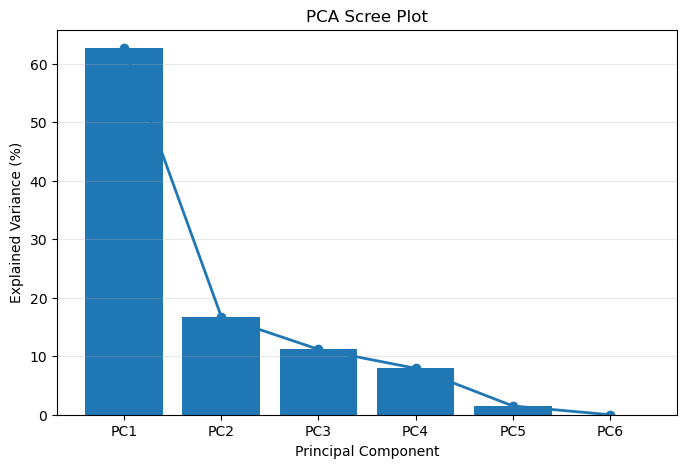

In [33]:
import matplotlib.pyplot as plt

# Explained variance ratios form PCA
explained_variance = pca.explained_variance_ratio_ * 100

components = [
    f"PC{i+1}"
    for i in range(len(explained_variance))
]

plt.figure(figsize=(8,5))

plt.bar(
    components,
    explained_variance
)

plt.plot(
    components,
    explained_variance,
    marker = "o",
    linewidth = 2
)

plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")

plt.grid(axis="y", alpha=0.3)

plt.show()


Figure 3. PCA Scree Plot. The first principal component explained 62.65% of the total variance in the maritime dataset, while the second principal components accounted for approximately 79.41% of the total variance. The sharp decline in explained varianceafter approximately 79.41% of the total variance. The sharp decline inexplained variance after the second component suggests that most of the information contained within the original six maritime features can be represented using a small number of latent dimensions. 

In [34]:
# Step 6: Plot it

In [11]:
pc_df = pd.DataFrame(
    X_pca[:, :3],
    columns=["PC1", "PC2", "PC3"]
)

pc_df["Week"] = weekly_df["Week"]

pc_df.sort_values(
    "PC1",
    ascending=False
)[["Week", "PC1"]].head(15)

,Week,PC1
169,2022-04-03,6.510425
246,2023-10-01,6.402827
234,2023-07-02,6.061388
182,2022-07-03,5.985893
208,2023-01-01,5.765094
143,2021-10-03,5.732479
221,2023-04-02,5.598544
195,2022-10-02,5.480778
130,2021-07-04,5.312998
117,2021-04-04,4.935324


In [12]:
pc_df["Month"] = pd.to_datetime(pc_df["Week"]).dt.month

pc_df["Quarter_Start"] = pc_df["Month"].isin([1,4,7,10])

pc_df.groupby("Quarter_Start")["PC1"].mean()


Quarter_Start
False   -0.388687
True     0.759706
Name: PC1, dtype: float64

1. Raw AIS data
You noticed unusually busy weeks:
2022-04-03
2022-07-03
2022-10-02
2023-01-01
2023-04-02
2023-07-02
2023-10-01
2. K-Means
The high-activity cluster was dominated by those same weeks.
3. Quarter analysis
Quarter-start weeks showed significantly higher:
Tankers
Cargo vessels
Unique vessels
with very small p-values.
4. PCA
Without knowing anything about quarters:
PCA built an "Overall Maritime Activity" factor.
The highest PC1 weeks were the same quarter-start weeks.
Average PC1 is much higher during quarter starts.
Toddler version
Imagine we have three detectives:
Detective #1: K-Means
"These weeks look different."
Detective #2: T-tests
"These weeks really do have more ships."
Detective #3: PCA
"I don't know anything about quarters, but these same weeks are the busiest."
When three independent detectives point to the same suspect, you start believing the story.
If this were my project
At this point I would call this a validated unsupervised finding:
Maritime activity exhibits a recurring quarterly cycle characterized by elevated tanker traffic, cargo traffic, and unique vessel counts during the first month of each quarter.
That's no longer just a hunch. You've now supported it with:
Descriptive statistics
K-Means clustering
Statistical testing
PCA dimensionality reduction
All pointing to the same conclusion.

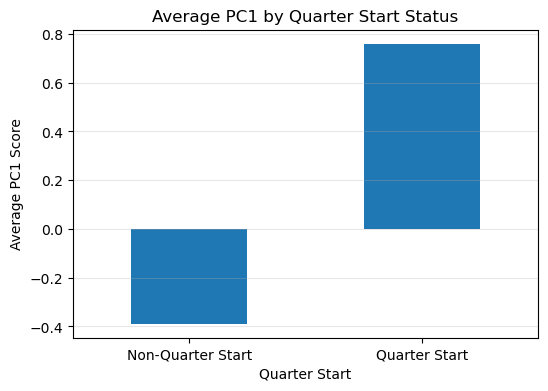

In [36]:
pc1_quarter = (
    pc_df.groupby("Quarter_Start")["PC1"].mean()
)

pc1_quarter.plot(
    kind = "bar",
    figsize=(6,4)
)

plt.title("Average PC1 by Quarter Start Status")
plt.ylabel("Average PC1 Score")
plt.xlabel("Quarter Start")
plt.xticks(
    [0,1],
     ["Non-Quarter Start", "Quarter Start"],
     rotation=0
)

plt.grid(axis="y", alpha=0.3)

plt.show()

Figure 4. Average PC1 by Quarter Start Status. The average value of the first principal component (PC1) was substantially higher during quarter start periods than during non-quarter start periods. Because PCA was performed without any calendar or seasonal information, this result suggests that the largest source of variation in maritime activity is associated with recurring quarterly shipping behavior. 

In [13]:
port_quarter = (
    combined_df
    .assign(
        Month=lambda x: pd.to_datetime(x["Week"]).dt.month,
        Quarter_Start=lambda x: x["Month"].isin([1,4,7,10])
    )
    .groupby(["Port","Quarter_Start"])[
        ["Tanker_Vessels","Cargo_Vessels","Unique_Vessels"]
    ]
    .mean()
    .reset_index()
)

port_quarter.head()

,Port,Quarter_Start,Tanker_Vessels,Cargo_Vessels,Unique_Vessels
0,Anchorage,False,0.637500,6.400000,7.037500
1,Anchorage,True,0.567568,6.216216,6.783784
2,Baltimore,False,20.889535,84.802326,105.691860
3,Baltimore,True,22.738636,93.397727,116.136364
4,Baton Rouge,False,0.019481,2.603896,2.623377


In [14]:
tanker_ports = (
    port_quarter
    .pivot(
        index="Port",
        columns="Quarter_Start",
        values="Tanker_Vessels"
    )
)

tanker_ports["Pct_Change"] = (
    (tanker_ports[True] - tanker_ports[False])
    / tanker_ports[False]
) * 100

tanker_ports.sort_values(
    "Pct_Change",
    ascending=False
)

Quarter_Start,False,True,Pct_Change
Port,,,
Tampa,10.197674,12.250000,20.125428
Norfolk,11.901163,14.102273,18.494915
Savannah,11.994186,14.125000,17.765390
Charleston,9.918605,11.556818,16.516573
Houston,258.918605,298.965909,15.467141
Los Angeles,43.872093,50.454545,15.003735
Mobile,16.994186,19.522727,14.878860
Boston,13.360465,15.136364,13.292191
Corpus Christi,60.715116,68.704545,13.158880


Port-level analysis revealed that the quarterly maritime activity cycle was widespread across the U.S. port network. Significant increases in tanker activity were observed across Gulf Coast energy ports, East Coast container ports, and West Coast trade hubs. This suggests the quarterly cycle reflects a broader logistics and trade phenomenon rather than being driven solely by oil-related shipping activity.

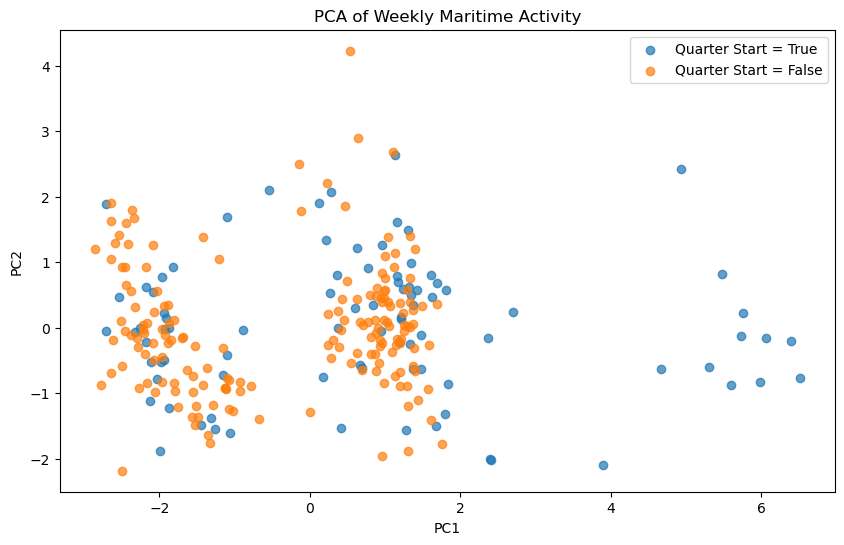

In [15]:
import matplotlib.pyplot as plt

pc_df["Quarter_Start"] = weekly_df["Quarter_Start"]

plt.figure(figsize=(10,6))

for group in [True, False]:
    subset = pc_df[pc_df["Quarter_Start"] == group]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.7,
        label=f"Quarter Start = {group}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Weekly Maritime Activity")
plt.legend()
plt.show()

PCA visualization revealed substantial overlap between quarter-start and non-quarter-start weeks. However, the highest values of the primary maritime activity component (PC1) were overwhelmingly associated with quarter-start periods, indicating that while quarter starts do not create a completely separate regime, they are disproportionately associated with the most active maritime weeks.

In [16]:
weekly_df["Year"] = pd.to_datetime(weekly_df["Week"]).dt.year

year_summary = (
    weekly_df
    .groupby(["Year", "Quarter_Start"])[
        ["Tanker_Vessels", "Cargo_Vessels", "Unique_Vessels"]
    ]
    .mean()
)

year_summary

Tanker_Vessels  Cargo_Vessels  Unique_Vessels
Year Quarter_Start                                               
2019 False             1021.611111    1992.111111     3013.722222
     True              1115.500000    2160.625000     3276.125000
2020 False              894.777778    1791.222222     2686.000000
     True              1029.000000    1983.812500     3012.812500
2021 False             1101.441176    2251.558824     3353.000000
     True              1195.277778    2407.777778     3603.055556
2022 False             1240.363636    2399.000000     3639.363636
     True              1309.157895    2559.263158     3868.421053
2023 False             1266.030303    2182.848485     3448.878788
     True              1386.263158    2513.315789     3899.578947

Key Finding
Across all five years (2019-2023), quarter-start weeks consistently exhibited higher tanker counts, cargo counts, and unique vessel counts than non-quarter-start weeks. PCA further showed that quarter-start periods are associated with higher values of the primary maritime activity component, suggesting that quarter starts represent a recurring high-activity maritime regime rather than isolated events.

In [17]:
from sklearn.preprocessing import StandardScaler

X = weekly_df[
    [
        "Tanker_Vessels",
        "Cargo_Vessels",
        "Draft",
        "Avg_SOG",
        "Avg_Length",
        "Unique_Vessels"
    ]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.decomposition import PCA

pca = PCA()

pca_result = pca.fit_transform(X_scaled)

In [19]:
weekly_df["PC1"] = pca_result[:, 0]
weekly_df["PC2"] = pca_result[:, 1]

In [20]:
weekly_df[["PC1", "PC2"]].head()

,PC1,PC2
0,-2.025858,-0.779023
1,-1.104338,1.688513
2,-1.152432,-0.729283
3,-0.881343,-0.038716
4,-1.068066,-0.795968


In [21]:
high_pc1_weeks = weekly_df.nlargest(20, "PC1")["Week"]

combined_df[
    combined_df["Week"].isin(high_pc1_weeks)
].groupby("Port")[
    ["Tanker_Vessels", "Cargo_Vessels", "Unique_Vessels"]
].sum().sort_values(
    "Tanker_Vessels",
    ascending=False
).head(20)

,Tanker_Vessels,Cargo_Vessels,Unique_Vessels
Port,,,
Houston,8414,3711,12125
Miami,3472,5946,9418
Port Arthur,3104,1587,4691
New Orleans,2258,5397,7655
Corpus Christi,1856,366,2222
New York,1555,3308,4863
Los Angeles,1427,3131,4558
Port Everglades,1280,1810,3090
Puerto Rico,1017,2371,3388


In [22]:
combined_df["Month"] = pd.to_datetime(combined_df["Week"]).dt.month

combined_df["Quarter_Month"] = (
    ((combined_df["Month"] - 1) % 3) + 1
)

combined_df["Quarter_Start"] = combined_df["Quarter_Month"] == 1

In [23]:
gulf_ports = [
    "Houston",
    "Port Arthur",
    "Corpus Christi",
    "New Orleans"
]

combined_df[
    combined_df["Port"].isin(gulf_ports)
].groupby(
    ["Port", "Quarter_Start"]
)[
    ["Tanker_Vessels", "Cargo_Vessels"]
].mean()

Tanker_Vessels  Cargo_Vessels
Port           Quarter_Start                               
Corpus Christi False               60.715116      13.633721
               True                68.704545      15.397727
Houston        False              258.918605     114.418605
               True               298.965909     133.431818
New Orleans    False               74.581395     160.470930
               True                84.034091     195.250000
Port Arthur    False              115.267442      62.459302
               True               122.897727      65.840909

In [24]:
gulf_ports = [
    "Houston",
    "Port Arthur",
    "Corpus Christi",
    "New Orleans"
]

combined_df["Gulf_Port"] = combined_df["Port"].isin(gulf_ports)

In [25]:
combined_df[
    combined_df["Gulf_Port"]
].groupby("Quarter_Start")[
    ["Tanker_Vessels",
     "Cargo_Vessels",
     "Unique_Vessels"]
].mean()

,Tanker_Vessels,Cargo_Vessels,Unique_Vessels
Quarter_Start,,,
False,127.370640,87.745640,215.116279
True,143.650568,102.480114,246.130682


In [26]:
combined_df["Year"] = pd.to_datetime(combined_df["Week"]).dt.year
combined_df["Month"] = pd.to_datetime(combined_df["Week"]).dt.month

combined_df["Quarter_Month"] = (
    ((combined_df["Month"] - 1) % 3) + 1
)

combined_df["Quarter_Start"] = combined_df["Quarter_Month"] == 1

In [27]:
year_pct = (
    combined_df.groupby(
        ["Year", "Quarter_Start"]
    )[
        ["Tanker_Vessels",
         "Cargo_Vessels",
         "Unique_Vessels"]
    ]
    .mean()
    .unstack()
)

year_pct

Tanker_Vessels            Cargo_Vessels             \
Quarter_Start          False      True          False      True    
Year                                                               
2019               34.116883  37.260960     66.526902  72.171190   
2020               29.992551  34.371608     60.040968  66.265136   
2021               37.942249  41.059160     77.561297  82.709924   
2022               42.860733  45.143376     82.897382  88.250454   
2023               43.701883  47.976321     75.349372  86.981785   

              Unique_Vessels              
Quarter_Start          False       True   
Year                                      
2019              100.643785  109.432150  
2020               90.033520  100.636743  
2021              115.503546  123.769084  
2022              125.758115  133.393829  
2023              119.051255  134.958106

In [28]:
year_pct_change = pd.DataFrame({
    "Tanker_Pct_Change": (
        (year_pct[("Tanker_Vessels", True)] - year_pct[("Tanker_Vessels", False)])
        / year_pct[("Tanker_Vessels", False)] * 100
    ),
    "Cargo_Pct_Change": (
        (year_pct[("Cargo_Vessels", True)] - year_pct[("Cargo_Vessels", False)])
        / year_pct[("Cargo_Vessels", False)] * 100
    ),
    "Unique_Vessels_Pct_Change": (
        (year_pct[("Unique_Vessels", True)] - year_pct[("Unique_Vessels", False)])
        / year_pct[("Unique_Vessels", False)] * 100
    )
})

year_pct_change

,Tanker_Pct_Change,Cargo_Pct_Change,Unique_Vessels_Pct_Change
Year,,,
2019,9.215605,8.484219,8.732149
2020,14.600480,10.366534,11.776973
2021,8.214882,6.638139,7.156090
2022,5.325720,6.457468,6.071747
2023,9.780901,15.437969,13.361346


<Axes: title={'center': 'Quarter Start Activity Increase by Year'}, xlabel='Year'>

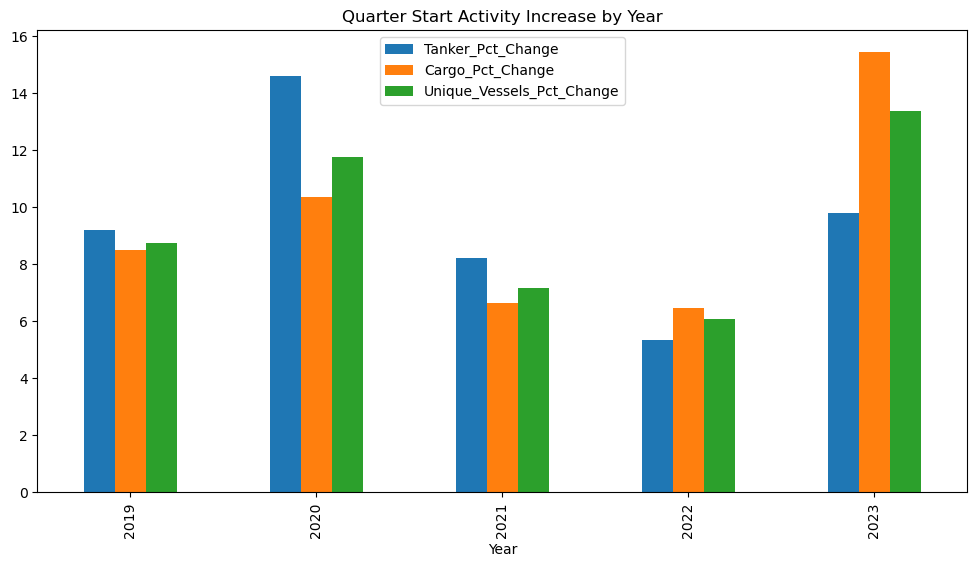

In [29]:
year_pct_change.plot(
    kind="bar",
    figsize=(12,6),
    title="Quarter Start Activity Increase by Year"
)